In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, plot_precision_recall_curve, plot_roc_curve
import warnings
warnings.filterwarnings("ignore")

# Reading the Data

In [2]:
train_df = pd.read_csv("/kaggle/input/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/titanic/test.csv")
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Cleaning the data

Cleaning up the train data by dropping 'Name','PassengerId', 'Ticket' and converting 'Sex' and 'Embark' columns to numeric data
the train sequence is then scaled and 'Survived' column is seperated to y_train

In [3]:
train_df['Sex'].replace('male', 0, inplace = True)
train_df['Sex'].replace('female', 1, inplace = True)
train_df['Embark'] = pd.factorize(train_df['Embarked'])[0] + 1
train_df['Cabin'] = pd.factorize(train_df['Cabin'])[0] + 1
train_df['Age'][train_df['Age'].isnull()] = round(np.mean(train_df['Age']), 2)
train_df.drop(['Name','PassengerId', 'Ticket','Embarked'], axis = 1 , inplace = True)
y_all = train_df['Survived']
x_all = train_df.drop('Survived', axis = 1 , inplace = False)

# Checking missing data in the dataset 

In [4]:
x_all.isnull().sum()

Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
Fare      0
Cabin     0
Embark    0
dtype: int64

In [5]:
x_all.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embark
0,3,0,22.0,1,0,7.2500,0,1
1,1,1,38.0,1,0,71.2833,1,2
2,3,1,26.0,0,0,7.9250,0,1
3,1,1,35.0,1,0,53.1000,2,1
4,3,0,35.0,0,0,8.0500,0,1


# Checking correlations

<AxesSubplot:>

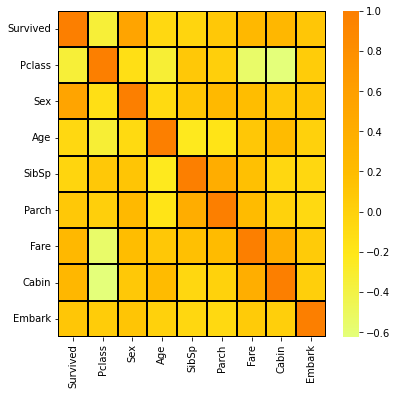

In [6]:
fig = plt.figure( figsize = ( 6,6))
data_correlations = train_df.corr(method = 'pearson')
sns.heatmap(data_correlations, cmap='Wistia', linecolor='black', linewidths=2)

# Making x and y for test and train

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x_all, y_all, test_size=0.1, random_state=101)

# Scaling the data and using Logistic Regression

In [8]:
scaler_train= StandardScaler()
scaler_train.fit(x_train)
scaler_test= StandardScaler()
scaler_test.fit(x_test)
x_train_scaled = scaler_train.transform(x_train)
x_test_scaled = scaler_test.transform(x_test)

log_model= LogisticRegression()
log_model.fit(x_train_scaled, y_train)

LogisticRegression()

# Predicting with Logistic Regression

In [9]:
y_pred= log_model.predict(x_test_scaled)

# Evaluation

In [10]:
accuracy_score(y_test, y_pred)

0.8222222222222222

In [11]:
confusion_matrix(y_test, y_pred)

array([[45,  6],
       [10, 29]])

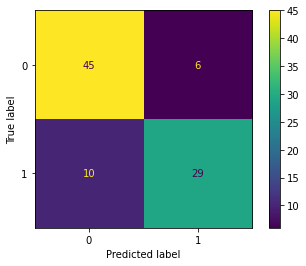

In [12]:
plot_confusion_matrix(log_model, x_test_scaled, y_test)

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        51
           1       0.83      0.74      0.78        39

    accuracy                           0.82        90
   macro avg       0.82      0.81      0.82        90
weighted avg       0.82      0.82      0.82        90



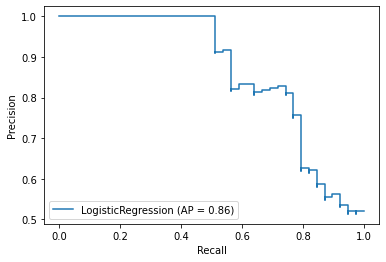

In [14]:
plot_precision_recall_curve(log_model, x_test_scaled, y_test)

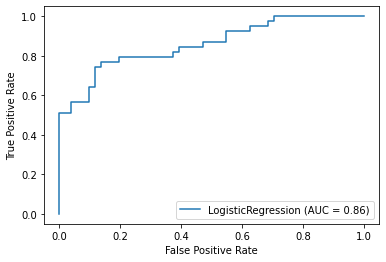

In [15]:
plot_roc_curve(log_model, x_test_scaled, y_test)